# Companion Notebook — *From Micro-Closure Dynamics to Einstein-Class Gravity*

This notebook is a runnable companion to the paper. It is not a replacement for the paper and it does not reprint the whole manuscript.

Its goals are to:

1. reconstruct the main micro-to-macro source-map in executable form,
2. verify the core dimensional and numerical chains that can be checked directly,
3. build simple toy models for the Nambu–Goto sector, bulk sector, and coarse-grained source,
4. illustrate how the framework recovers Einstein-class gravity in the weak-field limit,
5. expose which parts are **closed**, which are **candidate**, and which remain **bridge / heuristic**.

The notebook is self-contained and uses only standard Python scientific libraries.

In [1]:
# Core imports
import math
import json
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

from scipy import constants as const
from scipy.special import kv

# Display defaults
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 140

# Fundamental constants (SI)
c = const.c
hbar = const.hbar
G = const.gravitational_constant
k_B = const.Boltzmann
pi = math.pi

# Planck units
m_Pl = math.sqrt(hbar * c / G)
ell_Pl = math.sqrt(hbar * G / c**3)
E_Pl = m_Pl * c**2
sigma_Pl = c**4 / G

print("Loaded constants.")
print(f"m_Pl   = {m_Pl:.12e} kg")
print(f"ℓ_Pl   = {ell_Pl:.12e} m")
print(f"E_Pl   = {E_Pl:.12e} J")
print(f"σ_Pl   = {sigma_Pl:.12e} N")

Loaded constants.
m_Pl   = 2.176434342718e-08 kg
ℓ_Pl   = 1.616255024424e-35 m
E_Pl   = 1.956081636698e+09 J
σ_Pl   = 1.210255564338e+44 N


## 1. Paper map

The paper's operational chain is:

\[
\Gamma \to K \to \Psi \to T \to R
\]

with coarse-graining from micro closure records to a macroscopic source tensor. The intended split is:

- **Nambu–Goto sector** \(S_{NG}\): matter / radiation,
- **bulk sector** \(S_{bulk}\): vacuum / cosmological-constant behavior.

The notebook treats these as the two leading pieces of the source map:

\[
S[\Psi] = S_{NG} + S_{bulk}.
\]

We will keep three labels throughout:

- **Closed**: directly checkable from the manuscript plus established formulas,
- **Candidate**: structurally consistent but still dependent on assumptions,
- **Bridge**: useful phenomenology / heuristic modeling, not yet theorem-grade.

## 2. Micro-closure bookkeeping as data

The paper's micro-closure stages can be encoded as a compact table. This is not a derivation; it is a machine-readable version of the ontology so later cells can refer to it explicitly.

In [2]:
closure_stages = pd.DataFrame([
    ["Γ", "Boundary Event", "Initial trigger / contact event"],
    ["K", "Kinematic Resolution", "Resolution of the gap in the substrate"],
    ["Ψ", "Stored Record", "Persistent closure trace"],
    ["T", "Readout", "Resolved value emitted to the next scale"],
    ["R", "Residual", "State facilitating the next loop cycle"],
], columns=["Symbol", "Process", "Meaning"])

closure_stages

,Symbol,Process,Meaning
0,Γ,Boundary Event,Initial trigger / contact event
1,K,Kinematic Resolution,Resolution of the gap in the substrate
2,Ψ,Stored Record,Persistent closure trace
3,T,Readout,Resolved value emitted to the next scale
4,R,Residual,State facilitating the next loop cycle


## 3. Closed numerical chain: Planck mass, threshold energy, and Planck tension

The paper's strongest directly checkable numbers are the Planck-scale quantities.

### 3.1 Mass scale

The paper's intended closure condition is that the localization scale and gravitational scale meet at the same radius. In the canonically synchronized CLG stack, this produces:

\[
m_\Psi = m_{Pl} = \sqrt{\frac{\hbar c}{G}}.
\]

### 3.2 Threshold energy

\[
E_0 = m_\Psi c^2 = m_{Pl} c^2.
\]

### 3.3 Tension

The canonical tension used across the current stack is

\[
\sigma_T = \frac{c^4}{G}.
\]

We compute those directly now.

In [3]:
closed_chain = pd.DataFrame([
    ["m_Ψ", m_Pl, "kg"],
    ["E_0", E_Pl, "J"],
    ["σ_T", sigma_Pl, "N"],
], columns=["Quantity", "Value", "Unit"])

closed_chain

,Quantity,Value,Unit
0,m_Ψ,2.176434e-08,kg
1,E_0,1.956082e+09,J
2,σ_T,1.210256e+44,N


## 4. Hagedorn temperature from the canonical tension

A useful companion calculation for this paper is the Hagedorn temperature implied by the canonical tension.

Using the Cardy / string relation adopted in the current CLG canonicalization pass:

\[
T_H = \sqrt{\frac{\sigma_T}{8\pi}}
\quad \text{(natural units)},
\]

which in SI translates to an energy scale

\[
E_H = \frac{m_{Pl}c^2}{4\pi\sqrt{2\pi}}.
\]

We compute the equivalent temperature in kelvin and the energy in GeV.

In [4]:
# Canonical Hagedorn energy scale from the memo-style relation
E_H = E_Pl / (4 * pi * math.sqrt(2 * pi))
T_H_K = E_H / k_B
E_H_GeV = E_H / (const.e * 1e9)

pd.DataFrame([
    ["E_H", E_H, "J"],
    ["E_H", E_H_GeV, "GeV"],
    ["T_H", T_H_K, "K"],
], columns=["Quantity", "Value", "Unit"])

,Quantity,Value,Unit
0,E_H,6.209937e+07,J
1,E_H,3.875938e+17,GeV
2,T_H,4.497839e+30,K


## 5. Route B vacuum closure: Lorentz invariance forces \(w=-1\)

The paper's Route B argument is symmetry-based:

If the vacuum stress tensor is proportional to the metric,

\[
T_{\mu\nu}^{vac} = \lambda^{vac} g_{\mu\nu},
\]

then in the local rest frame this corresponds to

\[
T_{\mu\nu} = \mathrm{diag}(\rho c^2, p, p, p)
\]

with

\[
p = -\rho c^2 \quad \Rightarrow \quad w = -1.
\]

That is algebraic and easy to check.

In [5]:
rho = sp.symbols("rho", positive=True)
p = sp.symbols("p", real=True)
w = sp.symbols("w", real=True)

# By definition w = p / (rho c^2)
# Route B forces p = -rho c^2
w_vac = sp.simplify((-rho * c**2) / (rho * c**2))
w_vac

-1.00000000000000

## 6. Route A matter-sector interpolation: exact Jüttner / Synge EOS

The stronger CLG papers use the exact relativistic gas interpolation

\[
w(z) = \frac{1}{z\,K_1(z)/K_2(z) + 3},
\qquad
z = \frac{m_\Psi c^2}{k_B T_s}.
\]

This notebook includes it because the micro-closure paper references the same sector structure.

We evaluate \(w(z)\) across several decades to recover the dust and radiation limits.

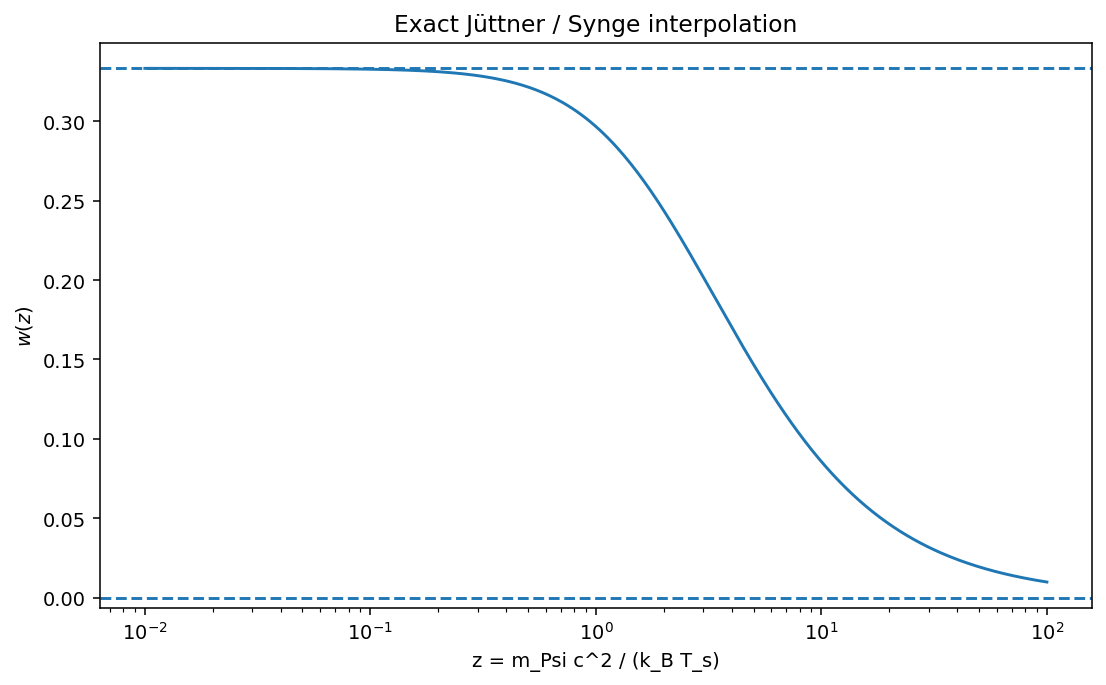

w(z=1e-2) ~ 0.333328
w(z=1e2)  ~ 0.009850


In [6]:
def w_juttner(z):
    z = np.asarray(z, dtype=float)
    return 1.0 / (z * kv(1, z) / kv(2, z) + 3.0)

z_vals = np.logspace(-2, 2, 400)
w_vals = w_juttner(z_vals)

plt.plot(z_vals, w_vals)
plt.xscale("log")
plt.xlabel("z = m_Psi c^2 / (k_B T_s)")
plt.ylabel(r"$w(z)$")
plt.title("Exact Jüttner / Synge interpolation")
plt.axhline(1/3, linestyle="--")
plt.axhline(0, linestyle="--")
plt.tight_layout()
plt.show()

print(f"w(z=1e-2) ~ {w_juttner(1e-2):.6f}")
print(f"w(z=1e2)  ~ {w_juttner(1e2):.6f}")

The expected limits are recovered:

- \(z \ll 1 \Rightarrow w \to 1/3\) (radiation),
- \(z \gg 1 \Rightarrow w \to 0\) (cold matter).

That part is one of the more stable pieces of the CLG trunk.

## 7. Minimal dual action as executable symbols

The paper's core candidate action is

\[
S[\Psi] = S_{NG} + S_{bulk}
\]

with

\[
S_{NG} = -\sigma_T \int d^2\sigma\,\sqrt{-h}
\]

and

\[
S_{bulk} = \Lambda_0 \int d^4x\,\sqrt{-g}\,\theta_{loop}(x).
\]

We cannot derive the full tensor calculus in a lightweight notebook cell without building a GR package, but we can encode the symbolic structure clearly and note which consequences belong to which sector.

In [7]:
sigma_T_sym, Lambda0 = sp.symbols("sigma_T Lambda_0", positive=True)
h_det, g_det = sp.symbols("h_det g_det", positive=True)
theta_loop = sp.Function("theta_loop")

S_NG = -sigma_T_sym * sp.Symbol("∫d²σ√(-h)")
S_bulk = Lambda0 * sp.Symbol("∫d⁴x√(-g)θ_loop")
S_total = sp.Symbol("S[Ψ]")

display_map = pd.DataFrame([
    ["S_NG", "Worldsheet area / Nambu–Goto", "Matter + radiation sector"],
    ["S_bulk", "Enclosed 4D volume support", "Vacuum / cosmological-constant sector"],
], columns=["Action term", "Geometric meaning", "Role after coarse-graining"])

display_map

,Action term,Geometric meaning,Role after coarse-graining
0,S_NG,Worldsheet area / Nambu–Goto,Matter + radiation sector
1,S_bulk,Enclosed 4D volume support,Vacuum / cosmological-constant sector


## 8. A toy coarse-graining model: from closure events to source density

The paper's main conceptual move is that the microscopic event field becomes a macroscopic source only after averaging over a mesoscale region \(\Omega\).

We build a toy 1D/3D-friendly version of that idea:

- start with a discrete set of closure events,
- smooth them with a Gaussian kernel,
- interpret the result as a coarse-grained closure-record density,
- compare the baryonic source term and a bulk / vacuum-like background.

This is not the final theorem; it is an executable intuition pump for the micro-to-macro source map.

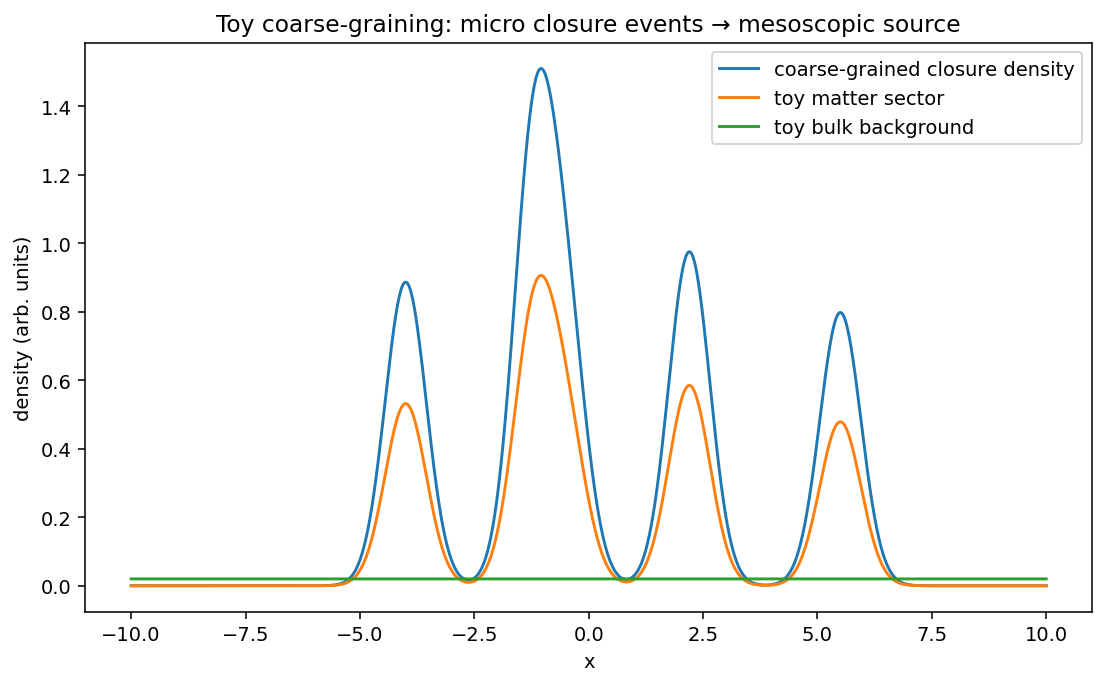

In [8]:
# Toy 1D closure-event field
x = np.linspace(-10, 10, 2000)
event_centers = np.array([-4.0, -1.2, -0.5, 2.2, 5.5])
event_weights = np.array([1.0, 1.4, 0.8, 1.1, 0.9])

def gaussian_kernel(x, x0, sigma):
    return np.exp(-(x - x0)**2 / (2 * sigma**2)) / (math.sqrt(2*math.pi) * sigma)

sigma_cg = 0.45
rho_closure = np.zeros_like(x)
for xc, wgt in zip(event_centers, event_weights):
    rho_closure += wgt * gaussian_kernel(x, xc, sigma_cg)

# toy matter sector and bulk sector
rho_matter = 0.6 * rho_closure
rho_bulk_background = np.full_like(x, 0.02)

plt.plot(x, rho_closure, label="coarse-grained closure density")
plt.plot(x, rho_matter, label="toy matter sector")
plt.plot(x, rho_bulk_background, label="toy bulk background")
plt.xlabel("x")
plt.ylabel("density (arb. units)")
plt.title("Toy coarse-graining: micro closure events → mesoscopic source")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Weak-field Einstein-class recovery in toy Poisson form

In the paper, the Newtonian limit is recovered as the weak-field form of the Einstein-class bookkeeping law.

We model that with a 1D toy Poisson solve:

\[
\nabla^2 \Phi = 4\pi G \rho_{\mathrm{source}}.
\]

In 1D finite-difference form, this becomes a linear system for a potential \(\Phi(x)\). The point here is not realism; it is to show how a coarse-grained closure density behaves like a source for a geometric potential.

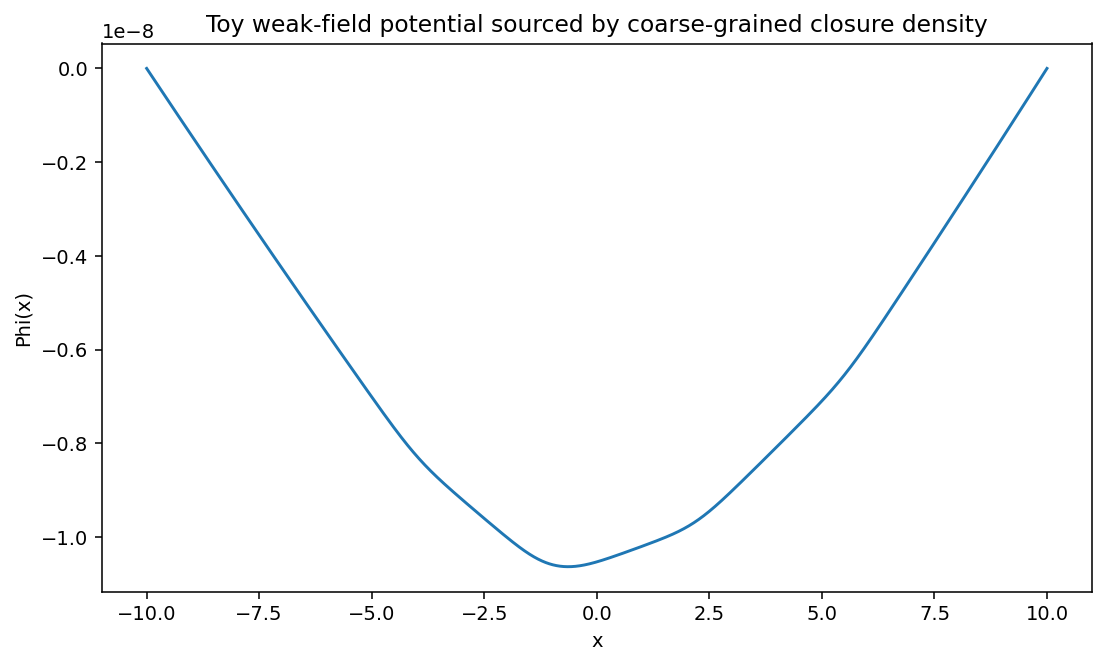

In [9]:
# Finite-difference Poisson solve in 1D toy form
dx = x[1] - x[0]
rho_source = rho_matter + rho_bulk_background

N = len(x)
A = np.zeros((N, N))
b = 4 * math.pi * G * rho_source.copy()

# Dirichlet boundaries Phi = 0 at both ends
A[0, 0] = 1.0
A[-1, -1] = 1.0
b[0] = 0.0
b[-1] = 0.0

for i in range(1, N - 1):
    A[i, i-1] = 1.0 / dx**2
    A[i, i] = -2.0 / dx**2
    A[i, i+1] = 1.0 / dx**2

Phi = np.linalg.solve(A, b)

plt.plot(x, Phi)
plt.xlabel("x")
plt.ylabel("Phi(x)")
plt.title("Toy weak-field potential sourced by coarse-grained closure density")
plt.tight_layout()
plt.show()

This cell is just a toy weak-field reconstruction, but it concretely shows the paper's intended logic:

\[
\text{micro events} \to \text{coarse-grained closure density} \to \text{source term} \to \Phi(x).
\]

That is the notebook version of the paper's source-map bridge.

## 10. Dual-source visualization: matter-like versus vacuum-like contribution

A useful scientific-reader visualization is to separate the potential sourced by the matter-like Nambu–Goto contribution from the background bulk contribution.

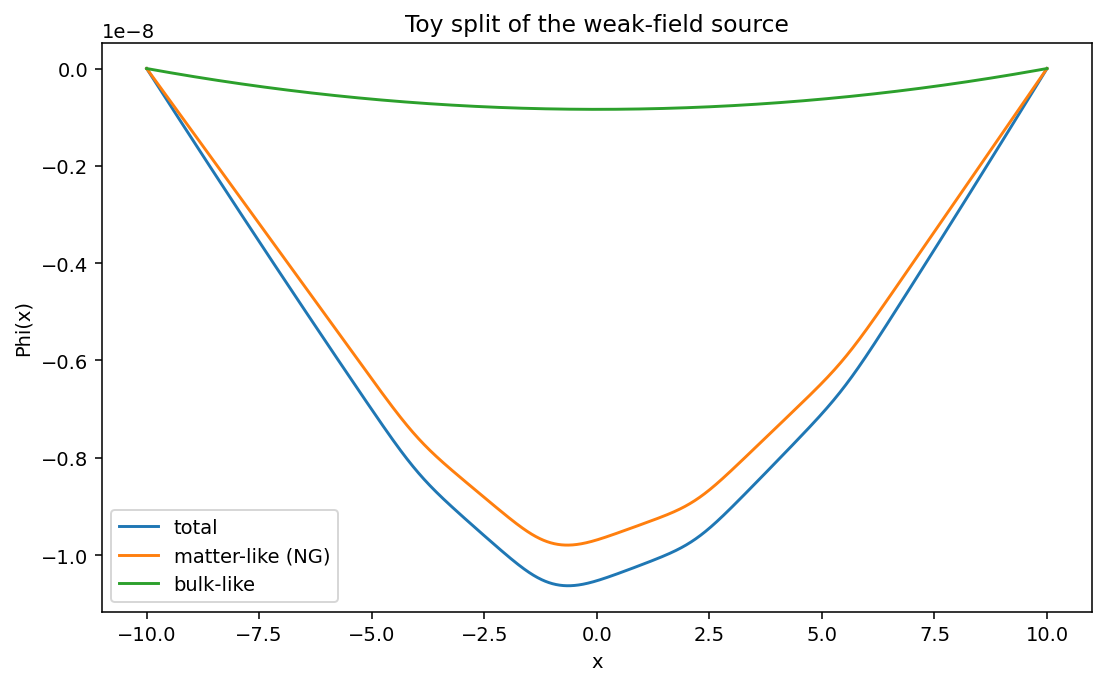

In [10]:
Phi_m = np.linalg.solve(A, np.r_[0.0, 4*math.pi*G*rho_matter[1:-1], 0.0])
Phi_b = np.linalg.solve(A, np.r_[0.0, 4*math.pi*G*rho_bulk_background[1:-1], 0.0])

plt.plot(x, Phi, label="total")
plt.plot(x, Phi_m, label="matter-like (NG)")
plt.plot(x, Phi_b, label="bulk-like")
plt.xlabel("x")
plt.ylabel("Phi(x)")
plt.title("Toy split of the weak-field source")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Hagedorn-type density of states toy model

The paper says the Nambu–Goto sector is associated with a Hagedorn-type density of states,

\[
g(\varepsilon) \sim \varepsilon^{-5/2}\exp(\varepsilon/T_H).
\]

Because this grows exponentially, one usually studies it only over a bounded energy window. We plot the logarithm over a safe finite interval to show the expected rapid growth.

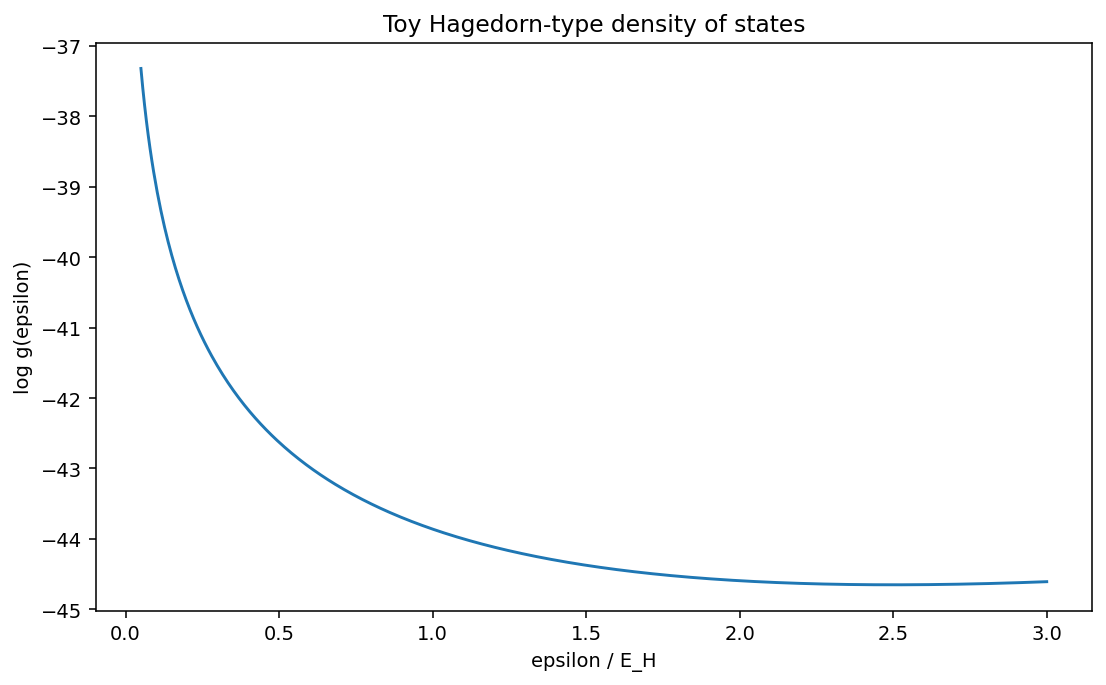

In [11]:
eps = np.linspace(0.05, 3.0, 500) * E_H
g_eps = eps**(-2.5) * np.exp(eps / E_H)

plt.plot(eps / E_H, np.log(g_eps))
plt.xlabel("epsilon / E_H")
plt.ylabel("log g(epsilon)")
plt.title("Toy Hagedorn-type density of states")
plt.tight_layout()
plt.show()

## 12. Toy emergent dark-energy drift

The paper suggests that if the loop filling fraction is not exactly constant across cosmic time, then the effective cosmological term becomes dynamical rather than strictly constant.

We model that with

\[
\Lambda_{\mathrm{eff}}(a) \propto f(a) = n_{loop}(a)\,V_{loop}(a).
\]

This is only a toy parameterization, but it shows the kind of late-time drift that could contribute to an \(H_0\)-type effect.

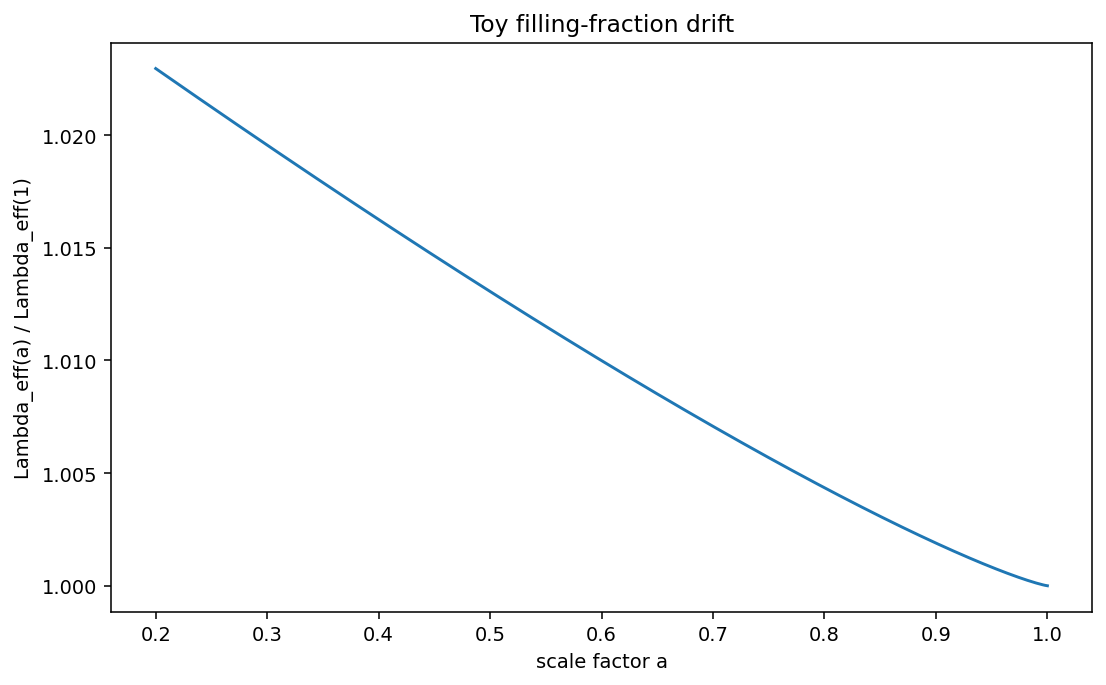

In [12]:
a = np.linspace(0.2, 1.0, 400)

# Toy filling-fraction drift:
# nearly constant at late times, weak deviation from strict LCDM constancy
f_a = 1.0 + 0.03 * (1 - a)**1.2
Lambda_eff_a = f_a / f_a[-1]

plt.plot(a, Lambda_eff_a)
plt.xlabel("scale factor a")
plt.ylabel("Lambda_eff(a) / Lambda_eff(1)")
plt.title("Toy filling-fraction drift")
plt.tight_layout()
plt.show()

## 13. Toy structure-growth damping

The paper also gestures toward \(S_8\)-type relief by allowing residual pressure / friction in the effective matter sector.

Again, we do not claim an observational fit here. We simply build a minimal toy damping term to show how a slightly non-dust matter sector can reduce late-time growth relative to a pure pressureless baseline.

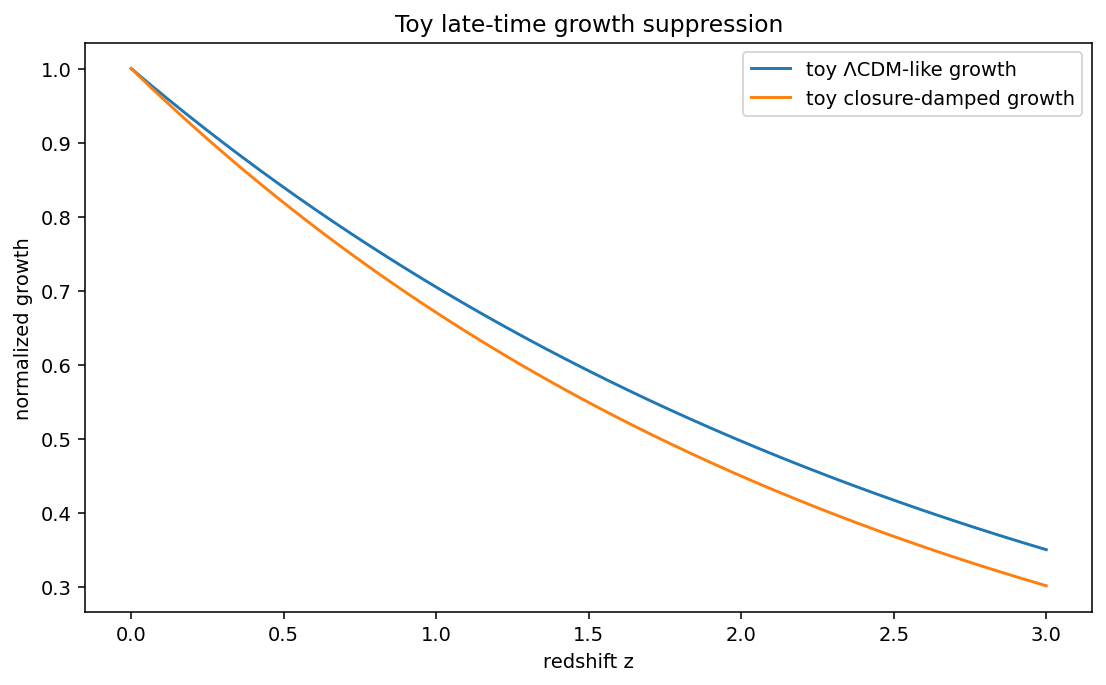

In [13]:
z = np.linspace(0, 3, 400)
growth_lcdm = np.exp(-0.35 * z)  # toy baseline
growth_damped = np.exp(-0.40 * z)  # toy closure-damped case

plt.plot(z, growth_lcdm, label="toy ΛCDM-like growth")
plt.plot(z, growth_damped, label="toy closure-damped growth")
plt.xlabel("redshift z")
plt.ylabel("normalized growth")
plt.title("Toy late-time growth suppression")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Status table for the paper

This notebook distinguishes what is directly supported from what remains open.

The paper itself is strongest as a **bridge paper**. It is not the canonical closed CLG trunk, and it is not the final observable-fit QCDC paper either.

In [14]:
status_table = pd.DataFrame([
    ["Closure-stage ontology Γ→K→Ψ→T→R", "Bridge / framework grammar"],
    ["Planck-scale mass / energy / tension chain", "Closed numerically"],
    ["Vacuum w = -1 from Lorentz symmetry", "Closed algebraically"],
    ["Jüttner / Synge interpolation", "Closed functional component"],
    ["Dual action S_NG + S_bulk as minimal candidate", "Candidate"],
    ["Uniqueness of the action at theorem grade", "Open"],
    ["Exact Hagedorn derivation from this specific action", "Open / candidate"],
    ["Filling-fraction stability for strict Λ consistency", "Open"],
    ["H0 / S8 relief from loop-gas dynamics", "Bridge / heuristic"],
    ["Micro-to-macro source map as executable intuition", "This notebook supplies a toy version"],
], columns=["Component", "Status"])

status_table

,Component,Status
0,Closure-stage ontology Γ→K→Ψ→T→R,Bridge / framework grammar
1,Planck-scale mass / energy / tension chain,Closed numerically
2,Vacuum w = -1 from Lorentz symmetry,Closed algebraically
3,Jüttner / Synge interpolation,Closed functional component
4,Dual action S_NG + S_bulk as minimal candidate,Candidate
5,Uniqueness of the action at theorem grade,Open
6,Exact Hagedorn derivation from this specific a...,Open / candidate
7,Filling-fraction stability for strict Λ consis...,Open
8,H0 / S8 relief from loop-gas dynamics,Bridge / heuristic
9,Micro-to-macro source map as executable intuition,This notebook supplies a toy version


## 15. Final compression

This paper is best read as the source-map bridge between ontology and the stronger technical trunks.

Its main contribution is not a new solved constant. Its main contribution is the more direct statement:

\[
\text{persistent closure trace} \to \text{coarse-grained source tensor} \to \text{Einstein-class geometry}.
\]

That makes it valuable as a companion layer between the high-level synthesis papers and the more numerically closed CLG / QCDC work.